**Text Classification: AG News Topic Classification**

Nama: Darryl Jetro Hezekia Sinaga

NPM: 2306249722

Kelas: Analisis Data Tidak Terstruktur (A)

## Install & Import Library

In [1]:
# Install library yang diperlukan
!pip install transformers torch scikit-learn seaborn wordcloud -q

In [2]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

## Load Dataset

In [4]:
df = pd.read_csv('/content/test.csv')

# Rename kolom
df.columns = ['label', 'title', 'description']

# Mapping label angka ke nama kategori
label_map = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
df['category'] = df['label'].map(label_map)

print(f'Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom')
print(f'Kolom: {list(df.columns)}')
df.head()

Jumlah data: 7600 baris, 4 kolom
Kolom: ['label', 'title', 'description', 'category']


,label,title,description,category
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...,Business
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",Sci/Tech
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Sci/Tech
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Sci/Tech
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Sci/Tech


## Exploratory Data Analysis (EDA)

In [6]:
# Informasi Dasar Dataset
print('Informasi Dataset')
print('-'*50)
print(f'Jumlah total data  : {len(df)}')
print(f'Jumlah kolom       : {len(df.columns)}')
print(f'Missing values     : {df.isnull().sum().sum()}')
print(f'Duplikasi data     : {df.duplicated().sum()}')
print()
print('Distribusi per kelas:')
print(df['category'].value_counts())

Informasi Dataset
--------------------------------------------------
Jumlah total data  : 7600
Jumlah kolom       : 4
Missing values     : 0
Duplikasi data     : 0

Distribusi per kelas:
category
Business    1900
Sci/Tech    1900
Sports      1900
World       1900
Name: count, dtype: int64


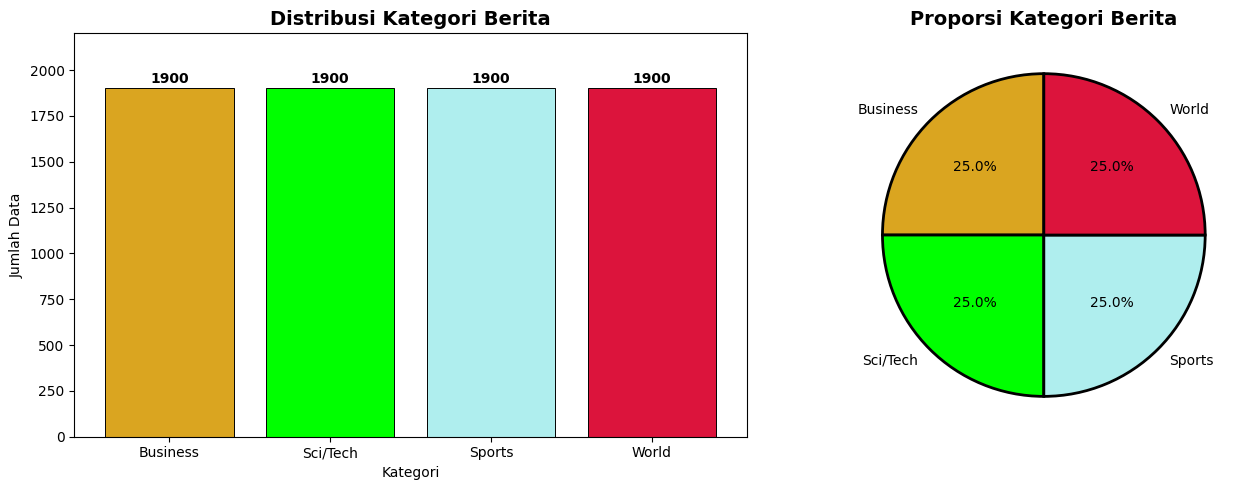

In [8]:
# Visualisasi Distribusi Kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['goldenrod', 'lime', 'paleturquoise', 'crimson']
counts = df['category'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribusi Kategori Berita', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, 2200)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Proporsi Kategori Berita', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Analisis Panjang Teks
df['title_len']  = df['title'].str.len()
df['desc_len']   = df['description'].str.len()
df['title_words'] = df['title'].str.split().str.len()
df['desc_words']  = df['description'].str.split().str.len()

print('Statistik Panjang Teks (jumlah karakter):')
print(df[['title_len', 'desc_len']].describe().round(1))
print()
print('Statistik Jumlah Kata:')
print(df[['title_words', 'desc_words']].describe().round(1))

Statistik Panjang Teks (jumlah karakter):
       title_len  desc_len
count     7600.0    7600.0
mean        41.9     192.4
std         13.5      63.2
min          6.0      37.0
25%         33.0     154.0
50%         41.0     187.0
75%         49.0     218.0
max         96.0     830.0

Statistik Jumlah Kata:
       title_words  desc_words
count       7600.0      7600.0
mean           6.8        31.0
std            2.1         9.8
min            1.0         4.0
25%            5.0        25.0
50%            7.0        30.0
75%            8.0        36.0
max           17.0       129.0


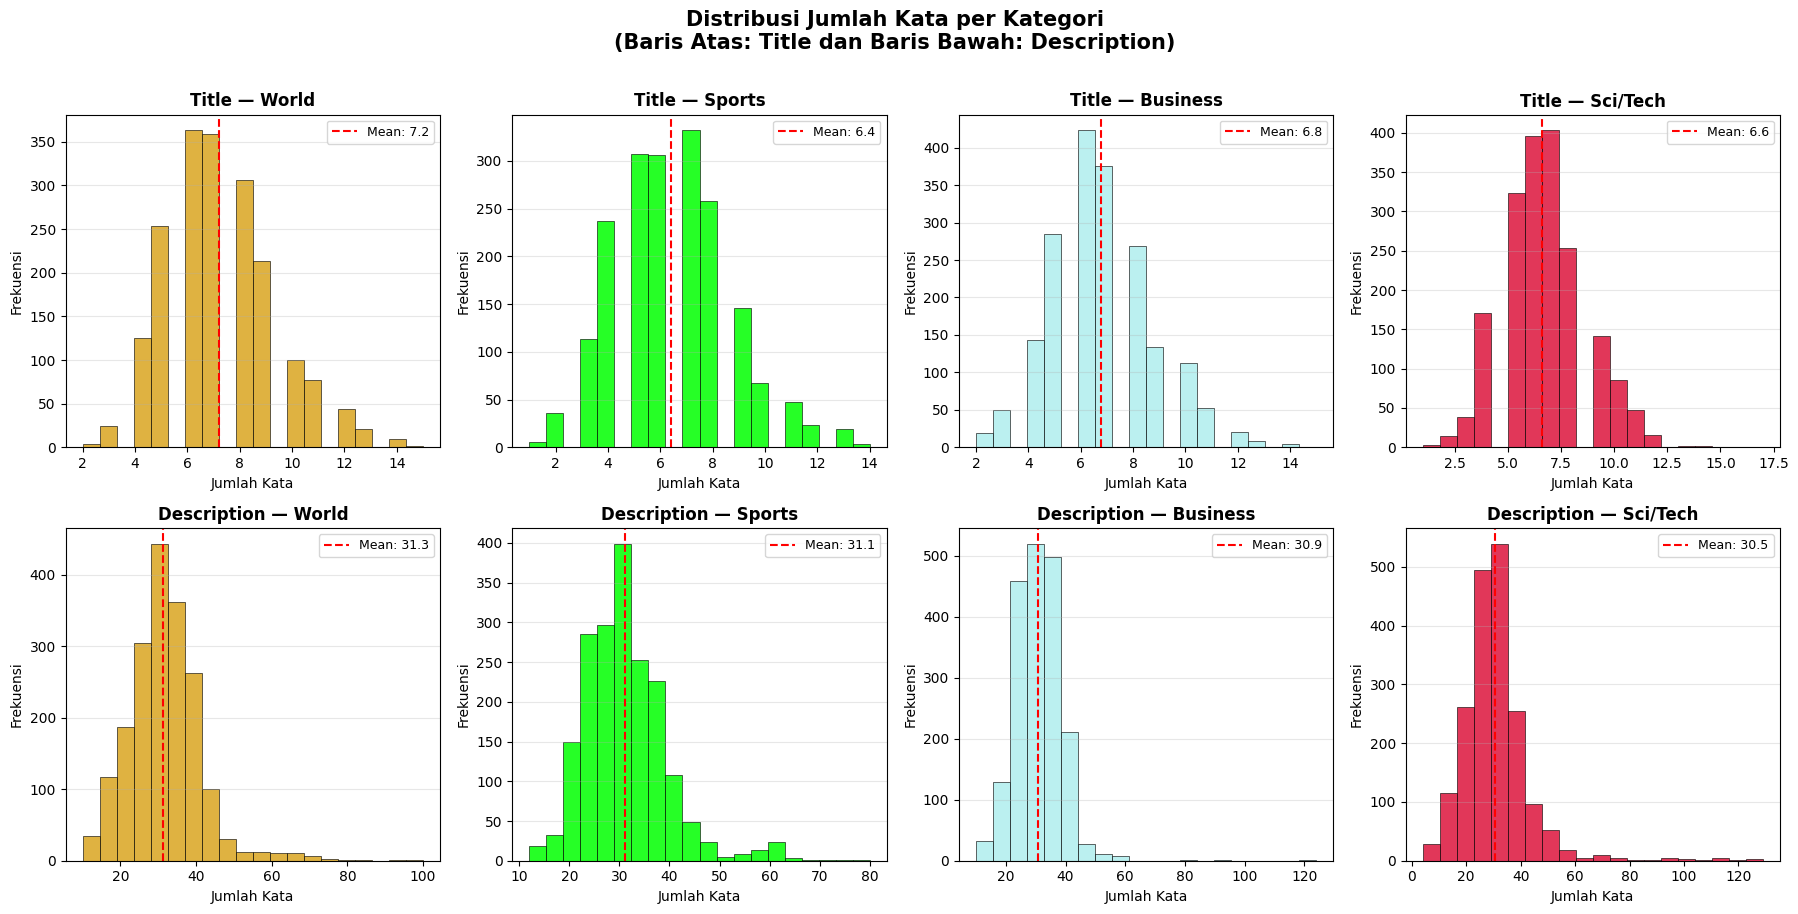

In [10]:
# Visualisasi Distribusi Jumlah Kata per Kategori
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (cat, color) in enumerate(zip(label_map.values(), colors)):
    subset = df[df['category'] == cat]

    # Plot baris atas (Title)
    axes[0][i].hist(subset['title_words'], bins=20, color=color, edgecolor='black', linewidth=0.5, alpha=0.85)
    axes[0][i].set_title(f'Title — {cat}', fontsize=12, fontweight='bold')
    axes[0][i].set_xlabel('Jumlah Kata')
    axes[0][i].set_ylabel('Frekuensi')
    axes[0][i].axvline(subset['title_words'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {subset["title_words"].mean():.1f}')
    axes[0][i].legend(fontsize=9)
    axes[0][i].grid(axis='y', alpha=0.3)

    # Plot baris bawah (Description)
    axes[1][i].hist(subset['desc_words'], bins=20, color=color, edgecolor='black', linewidth=0.5, alpha=0.85)
    axes[1][i].set_title(f'Description — {cat}', fontsize=12, fontweight='bold')
    axes[1][i].set_xlabel('Jumlah Kata')
    axes[1][i].set_ylabel('Frekuensi')
    axes[1][i].axvline(subset['desc_words'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {subset["desc_words"].mean():.1f}')
    axes[1][i].legend(fontsize=9)
    axes[1][i].grid(axis='y', alpha=0.3)

fig.suptitle('Distribusi Jumlah Kata per Kategori\n(Baris Atas: Title dan Baris Bawah: Description)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Contoh Berita per Kategori
print('Contoh Berita per Kategori')
print('='*60)
for cat in label_map.values():
    sample = df[df['category'] == cat].iloc[0]
    print(f'\n[{cat}]')
    print(f'Title      : {sample["title"]}')
    print(f'Description: {sample["description"][:120]}...')

Contoh Berita per Kategori

[World]
Title      : Sister of man who died in Vancouver police custody slams chief (Canadian Press)
Description: Canadian Press - VANCOUVER (CP) - The sister of a man who died after a violent confrontation with police has demanded th...

[Sports]
Title      : Giddy Phelps Touches Gold for First Time
Description: Michael Phelps won the gold medal in the 400 individual medley and set a world record in a time of 4 minutes 8.26 second...

[Business]
Title      : Fears for T N pension after talks
Description: Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal...

[Sci/Tech]
Title      : The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com)
Description: SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest f...


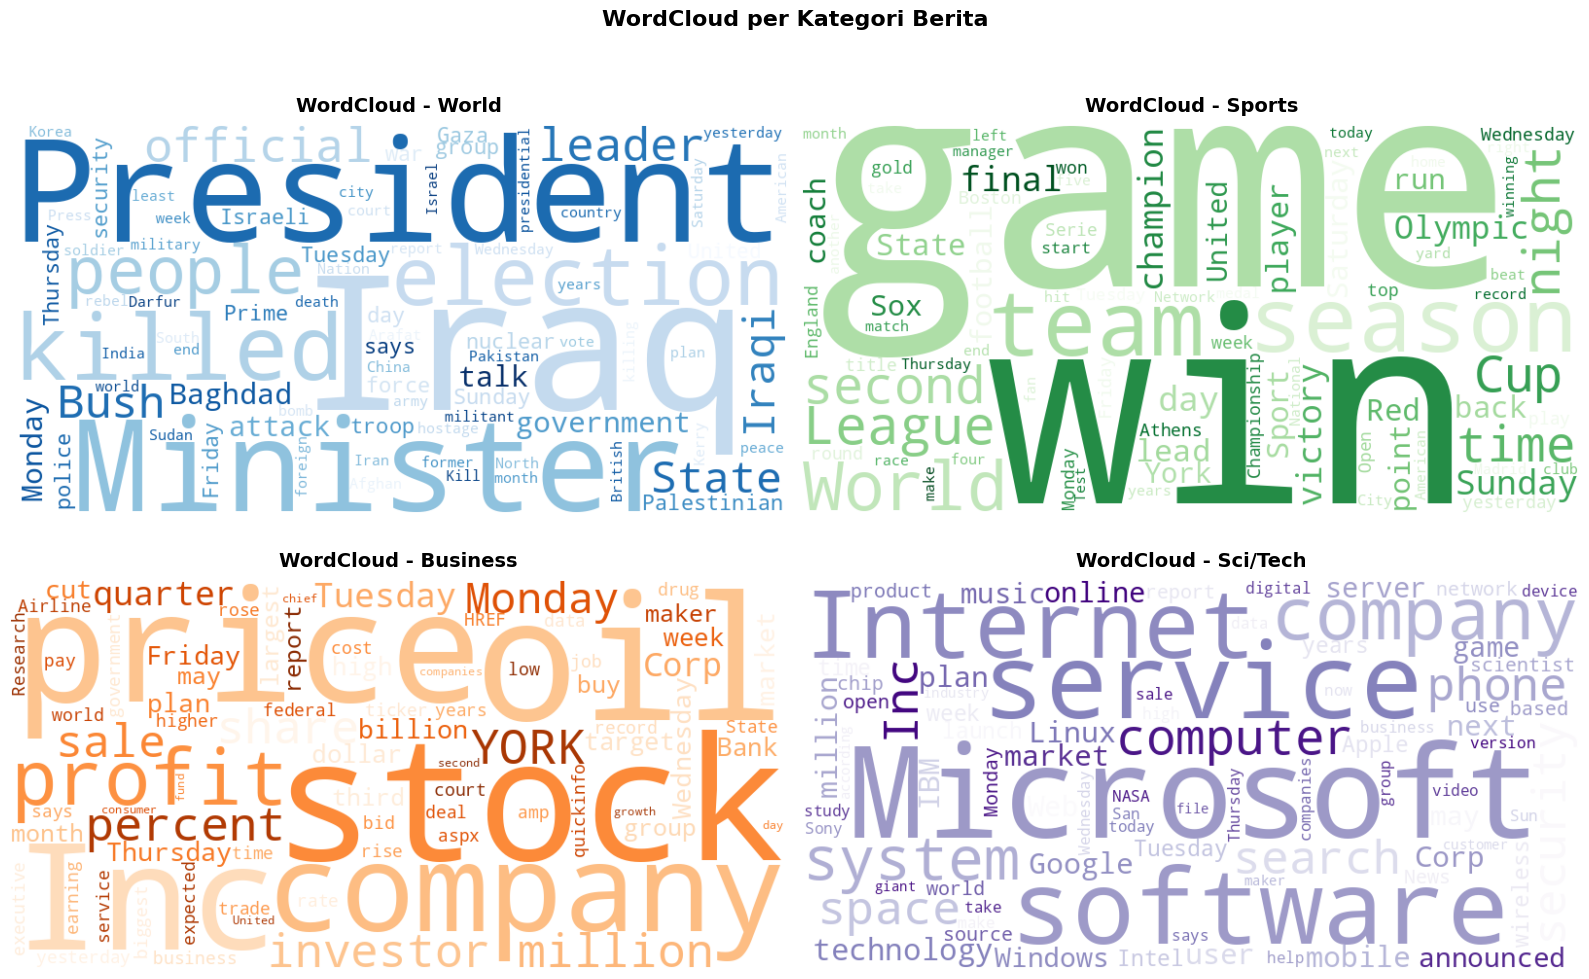

In [12]:
# Preprocessing untuk wordcloud (menghapus noise dari format HTML)
def clean_for_wordcloud(text):
    text = re.sub(r'&\w+;', ' ', text)
    text = re.sub(r'\\[ntr]', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\b\w{1,2}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

custom_stopwords = STOPWORDS.union({
    'said', 'will', 'one', 'two', 'three', 'new', 'say', 'also',
    'year', 'last', 'first', 'Reuters', 'AFP', 'FullQuote', 'quot'
})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
wc_colors = ['Blues', 'Greens', 'Oranges', 'Purples']

for i, (cat, cmap) in enumerate(zip(label_map.values(), wc_colors)):
    raw_text = ' '.join(df[df['category'] == cat]['title'] + ' ' + df[df['category'] == cat]['description'])
    clean_text = clean_for_wordcloud(raw_text)

    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=cmap,
        max_words=80,
        stopwords=custom_stopwords,
        collocations=False,
        min_word_length=3
    ).generate(clean_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'WordCloud - {cat}', fontsize=14, fontweight='bold', pad=10)

plt.suptitle('WordCloud per Kategori Berita', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordcloud_per_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing Teks

In [13]:
# Fungsi preprocessing teks untuk model ML standar
def preprocess_text(text):
    text = text.lower()
    # Hapus karakter spesial
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Fungsi preprocessing teks untuk BERT
def preprocess_bert(text):
    text = re.sub(r'\\n|\\t', ' ', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Menggabungkan title + description
df['text_combined']      = df['title'] + ' ' + df['description']
df['text_clean']         = df['text_combined'].apply(preprocess_text)
df['text_clean_bert']    = df['text_combined'].apply(preprocess_bert)

print('Contoh hasil preprocessing:')
print(f'\nORIGINAL  : {df["text_combined"].iloc[0][:150]}')
print(f'\nCLEAN ML  : {df["text_clean"].iloc[0][:150]}')
print(f'\nCLEAN BERT: {df["text_clean_bert"].iloc[0][:150]}')

Contoh hasil preprocessing:

ORIGINAL  : Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Fed

CLEAN ML  : fears for t n pension after talks unions representing workers at turner newall say they are disappointed after talks with stricken parent firm federal

CLEAN BERT: Fears for T N pension after talks Unions representing workers at Turner Newall say they are 'disappointed' after talks with stricken parent firm Feder


## Persiapan Data (Train-Validation-Test Split)

In [14]:
# Label encoding
df['label_enc'] = df['label'] - 1

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

print('Label encoding:')
for i, name in enumerate(class_names):
    print(f'  {i} = {name}')

Label encoding:
  0 = World
  1 = Sports
  2 = Business
  3 = Sci/Tech


In [15]:
# Split Data: Train (80%), Validation (10%), Test (10%)
# Split pertama (train+val vs test)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df['text_clean'], df['label_enc'],
    test_size=0.10, random_state=42, stratify=df['label_enc']
)

# Split kedua (train vs val)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.111, random_state=42, stratify=y_trainval
)

# Split untuk BERT (teks bersih ringan)
X_trainval_bert = df.loc[X_trainval.index, 'text_clean_bert']
X_test_bert     = df.loc[X_test.index,    'text_clean_bert']
X_train_bert    = df.loc[X_train.index,   'text_clean_bert']
X_val_bert      = df.loc[X_val.index,     'text_clean_bert']

print('Distribusi split data:')
print(f'  Train      : {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)')
print(f'  Validation : {len(X_val):,} ({len(X_val)/len(df)*100:.1f}%)')
print(f'  Test       : {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)')

Distribusi split data:
  Train      : 6,080 (80.0%)
  Validation : 760 (10.0%)
  Test       : 760 (10.0%)


## Model Baseline ML 1: TF-IDF dan Logistic Regression

In [16]:
# Feature Extraction dengan TF-IDF
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Shape TF-IDF train: {X_train_tfidf.shape}')
print(f'Shape TF-IDF val  : {X_val_tfidf.shape}')
print(f'Shape TF-IDF test : {X_test_tfidf.shape}')

Shape TF-IDF train: (6080, 33479)
Shape TF-IDF val  : (760, 33479)
Shape TF-IDF test : (760, 33479)


In [17]:
# Training Logistic Regression
lr_model = LogisticRegression(
    C=5.0,
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)

# Evaluasi pada validation set
y_val_pred_lr = lr_model.predict(X_val_tfidf)
lr_val_acc    = accuracy_score(y_val, y_val_pred_lr)
print(f'Logistic Regression - Validation Accuracy: {lr_val_acc:.4f} ({lr_val_acc*100:.2f}%)')

Logistic Regression - Validation Accuracy: 0.8711 (87.11%)


In [18]:
# Evaluasi Logistic Regression pada Test Set
y_test_pred_lr = lr_model.predict(X_test_tfidf)
lr_test_acc    = accuracy_score(y_test, y_test_pred_lr)

print('Evaluasi Logistic Regression untuk Test Set')
print('-'*55)
print(f'Accuracy: {lr_test_acc:.4f} ({lr_test_acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_test_pred_lr, target_names=class_names))

Evaluasi Logistic Regression untuk Test Set
-------------------------------------------------------
Accuracy: 0.8750 (87.50%)

Classification Report:
              precision    recall  f1-score   support

       World       0.89      0.88      0.89       190
      Sports       0.91      0.94      0.93       190
    Business       0.88      0.81      0.84       190
    Sci/Tech       0.82      0.87      0.84       190

    accuracy                           0.88       760
   macro avg       0.88      0.88      0.87       760
weighted avg       0.88      0.88      0.87       760



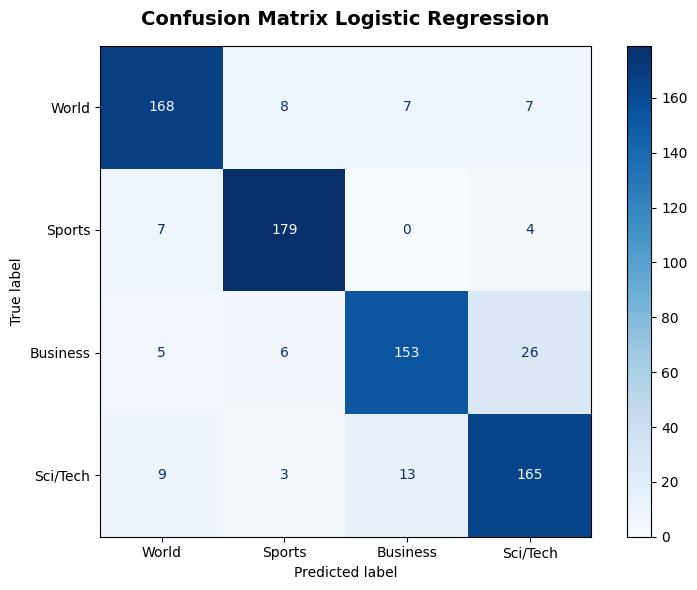

In [19]:
# Confusion Matrix Logistic Regression
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix Logistic Regression', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Baseline ML 2: TF-IDF dan Linear SVM

In [20]:
# Training Linear SVM
svm_model = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=42
)
svm_model.fit(X_train_tfidf, y_train)

# Evaluasi pada validation set
y_val_pred_svm = svm_model.predict(X_val_tfidf)
svm_val_acc    = accuracy_score(y_val, y_val_pred_svm)
print(f'Akurasi Validasi Linear SVM: {svm_val_acc:.4f} ({svm_val_acc*100:.2f}%)')

Akurasi Validasi Linear SVM: 0.8684 (86.84%)


In [21]:
# Evaluasi Linear SVM pada Test Set
y_test_pred_svm = svm_model.predict(X_test_tfidf)
svm_test_acc    = accuracy_score(y_test, y_test_pred_svm)

print('Evaluasi Linear SVM untuk Test Set')
print('-'*55)
print(f'Accuracy: {svm_test_acc:.4f} ({svm_test_acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_test_pred_svm, target_names=class_names))

Evaluasi Linear SVM untuk Test Set
-------------------------------------------------------
Accuracy: 0.8776 (87.76%)

Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.87      0.89       190
      Sports       0.91      0.95      0.93       190
    Business       0.87      0.82      0.85       190
    Sci/Tech       0.82      0.87      0.85       190

    accuracy                           0.88       760
   macro avg       0.88      0.88      0.88       760
weighted avg       0.88      0.88      0.88       760



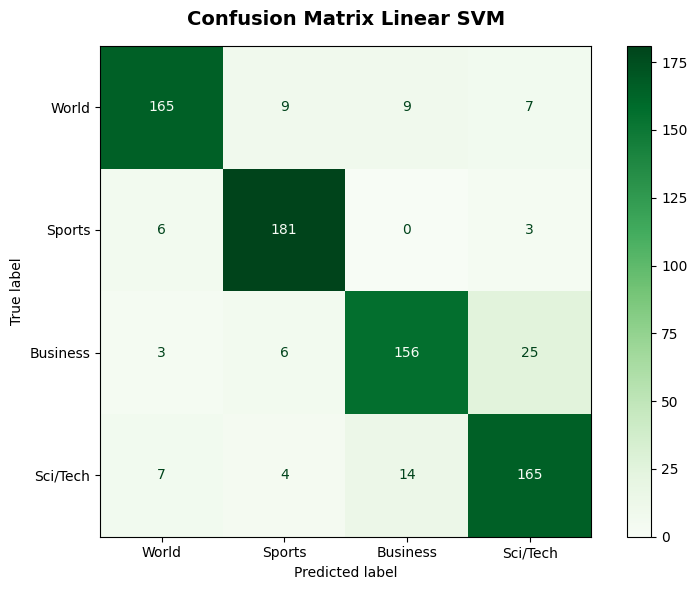

In [22]:
# Confusion Matrix Linear SVM
cm_svm = confusion_matrix(y_test, y_test_pred_svm)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Confusion Matrix Linear SVM', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('cm_linear_svm.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Utama: BERT Fine-tuning

In [24]:
# Dataset Class untuk PyTorch
class AGNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens    = True,
            max_length            = self.max_len,
            padding               = 'max_length',
            truncation            = True,
            return_attention_mask = True,
            return_tensors        = 'pt'
        )

        return {
            'input_ids'      : encoding['input_ids'].flatten(),
            'attention_mask' : encoding['attention_mask'].flatten(),
            'label'          : torch.tensor(label, dtype=torch.long)
        }

print('Dataset class berhasil didefinisikan')

Dataset class berhasil didefinisikan


In [25]:
# Load Tokenizer dan Buat DataLoader
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 32

print(f'Loading tokenizer: {MODEL_NAME} ...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Buat dataset
train_dataset = AGNewsDataset(X_train_bert, y_train, tokenizer, MAX_LEN)
val_dataset   = AGNewsDataset(X_val_bert,   y_val,   tokenizer, MAX_LEN)
test_dataset  = AGNewsDataset(X_test_bert,  y_test,  tokenizer, MAX_LEN)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches     : {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches      : {len(test_loader)}')

Loading tokenizer: bert-base-uncased ...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches     : 190
Validation batches: 24
Test batches      : 24


In [27]:
# Load Model BERT
NUM_CLASSES = 4
EPOCHS      = 3
LR          = 2e-5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Loading BERT model: {MODEL_NAME} ...')
bert_model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    output_attentions=False,
    output_hidden_states=False
)
bert_model = bert_model.to(device)

# Optimizer & Scheduler
optimizer = AdamW(bert_model.parameters(), lr=LR, eps=1e-8, weight_decay=0.01, fused=False)

total_steps    = len(train_loader) * EPOCHS
warmup_steps   = int(0.1 * total_steps)
scheduler      = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')
print('Model siap untuk training')

Loading BERT model: bert-base-uncased ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps : 570
Warmup steps         : 57
Model siap untuk training


In [28]:
# Training Loop BERT
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss
            logits  = outputs.logits

            total_loss += loss.item()
            preds       = torch.argmax(logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


# Main Training
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print('Mulai Training BERT')
print('-'*55)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(bert_model, train_loader, optimizer, scheduler, device)
    val_loss,   val_acc, _, _ = eval_epoch(bert_model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

print('Training selesai')

Mulai Training BERT
-------------------------------------------------------
Epoch 1/3 | Train Loss: 0.6355 | Train Acc: 0.7760 | Val Loss: 0.3122 | Val Acc: 0.9013
Epoch 2/3 | Train Loss: 0.2370 | Train Acc: 0.9270 | Val Loss: 0.2632 | Val Acc: 0.9158
Epoch 3/3 | Train Loss: 0.1542 | Train Acc: 0.9563 | Val Loss: 0.2594 | Val Acc: 0.9211
Training selesai


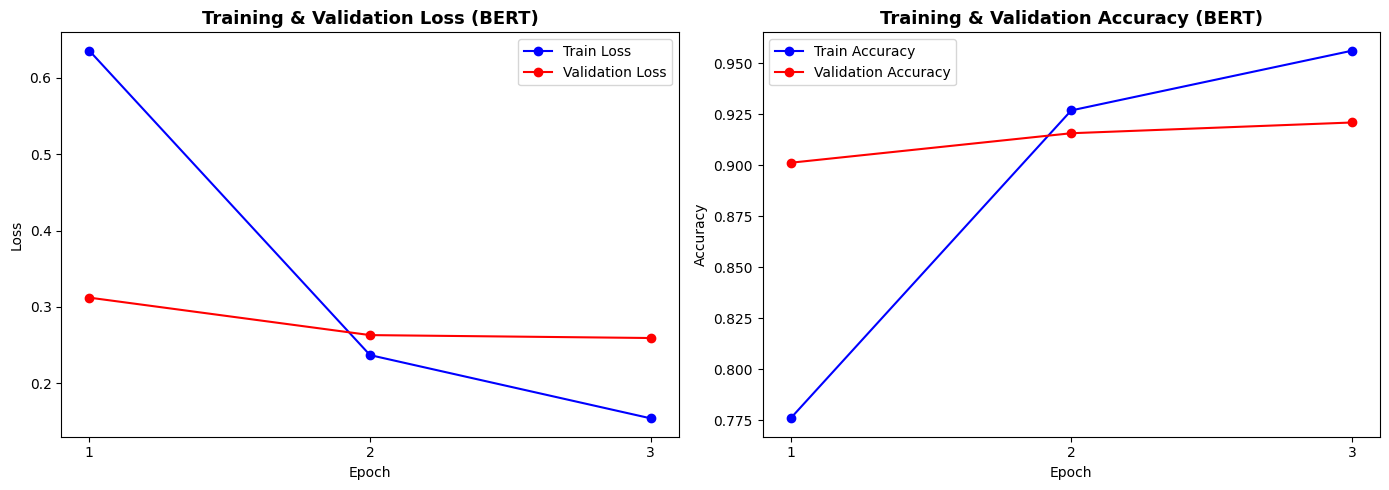

In [29]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'bo-', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'ro-', label='Validation Loss')
axes[0].set_title('Training & Validation Loss (BERT)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

axes[1].plot(epochs_range, history['train_acc'], 'bo-', label='Train Accuracy')
axes[1].plot(epochs_range, history['val_acc'],   'ro-', label='Validation Accuracy')
axes[1].set_title('Training & Validation Accuracy (BERT)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('bert_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Evaluasi BERT pada Test Set
_, bert_test_acc, y_test_pred_bert, y_test_true_bert = eval_epoch(bert_model, test_loader, device)

print('Evaluasi Bert untuk Test Set')
print('-'*55)
print(f'Accuracy: {bert_test_acc:.4f} ({bert_test_acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test_true_bert, y_test_pred_bert, target_names=class_names))

Evaluasi Bert untuk Test Set
-------------------------------------------------------
Accuracy: 0.9092 (90.92%)

Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.91      0.91       190
      Sports       0.95      0.99      0.97       190
    Business       0.88      0.85      0.87       190
    Sci/Tech       0.89      0.88      0.89       190

    accuracy                           0.91       760
   macro avg       0.91      0.91      0.91       760
weighted avg       0.91      0.91      0.91       760



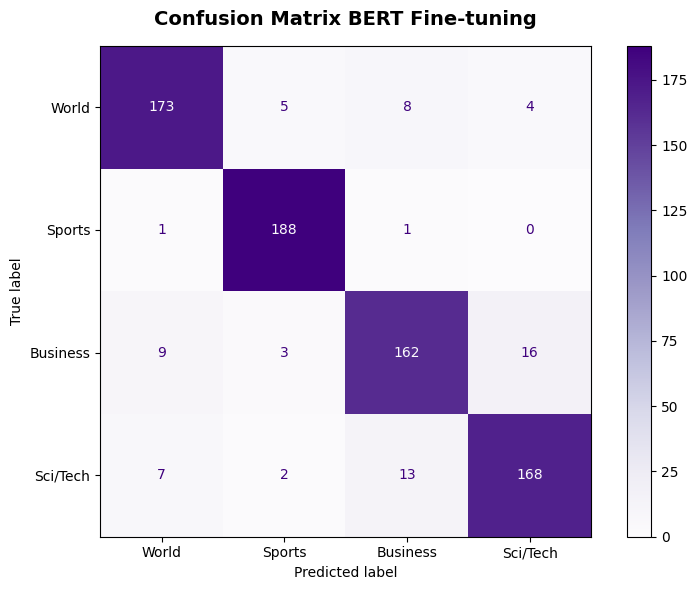

In [32]:
# Confusion Matrix BERT
cm_bert = confusion_matrix(y_test_true_bert, y_test_pred_bert)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Purples')
ax.set_title('Confusion Matrix BERT Fine-tuning', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('cm_bert.png', dpi=150, bbox_inches='tight')
plt.show()

## Perbandingan Ketiga Model

In [33]:
# Tabel Perbandingan Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall'   : recall_score(y_true, y_pred, average='weighted'),
        'F1-Score' : f1_score(y_true, y_pred, average='weighted')
    }

metrics_lr   = get_metrics(y_test, y_test_pred_lr)
metrics_svm  = get_metrics(y_test, y_test_pred_svm)
metrics_bert = get_metrics(y_test_true_bert, y_test_pred_bert)

results_df = pd.DataFrame({
    'Logistic Regression' : metrics_lr,
    'Linear SVM'          : metrics_svm,
    'BERT Fine-tuning'    : metrics_bert
}).T.round(4)

print('='*60)
print('Perbandingan Performa Ketiga Model')
print('='*60)
print(results_df.to_string())
print()
print(f'Model Terbaik: {results_df["F1-Score"].idxmax()} '
      f'(F1-Score: {results_df["F1-Score"].max():.4f})')

Perbandingan Performa Ketiga Model
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8750     0.8758  0.8750    0.8747
Linear SVM             0.8776     0.8783  0.8776    0.8773
BERT Fine-tuning       0.9092     0.9085  0.9092    0.9087

Model Terbaik: BERT Fine-tuning (F1-Score: 0.9087)


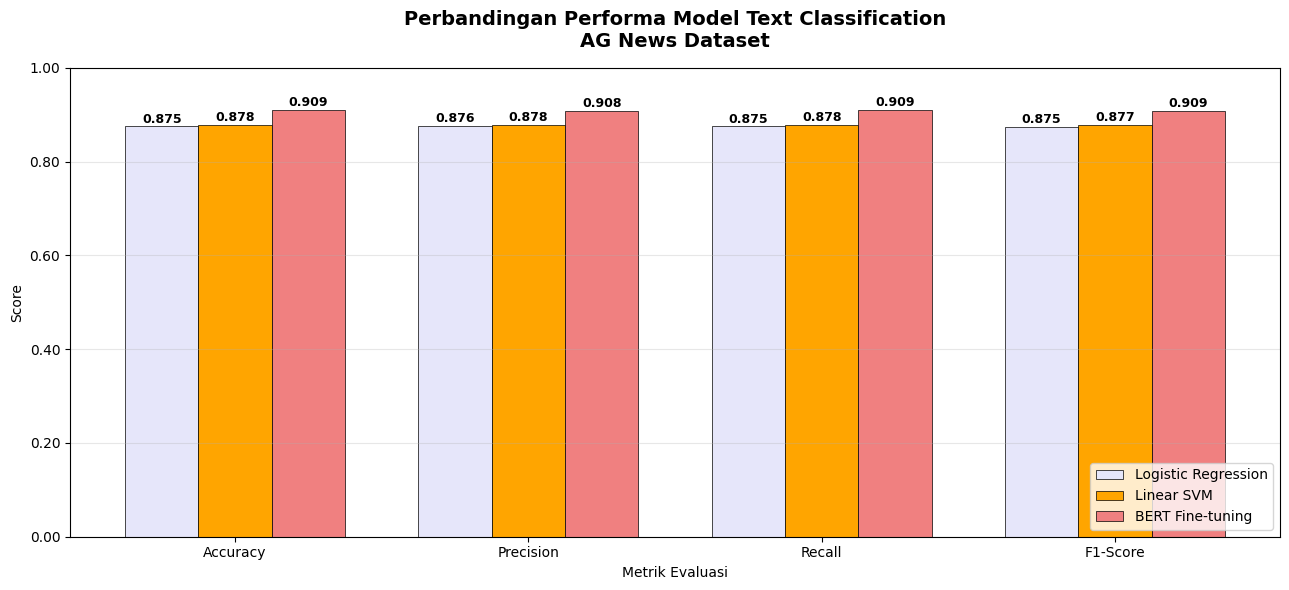

In [34]:
# Visualisasi Perbandingan Model
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models       = ['Logistic Regression', 'Linear SVM', 'BERT Fine-tuning']
bar_colors   = ['lavender', 'orange', 'lightcoral']

x     = np.arange(len(metrics_list))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model, color) in enumerate(zip(models, bar_colors)):
    vals = [results_df.loc[model, m] for m in metrics_list]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Perbandingan Performa Model Text Classification\nAG News Dataset',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Score')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0, 1.00)
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

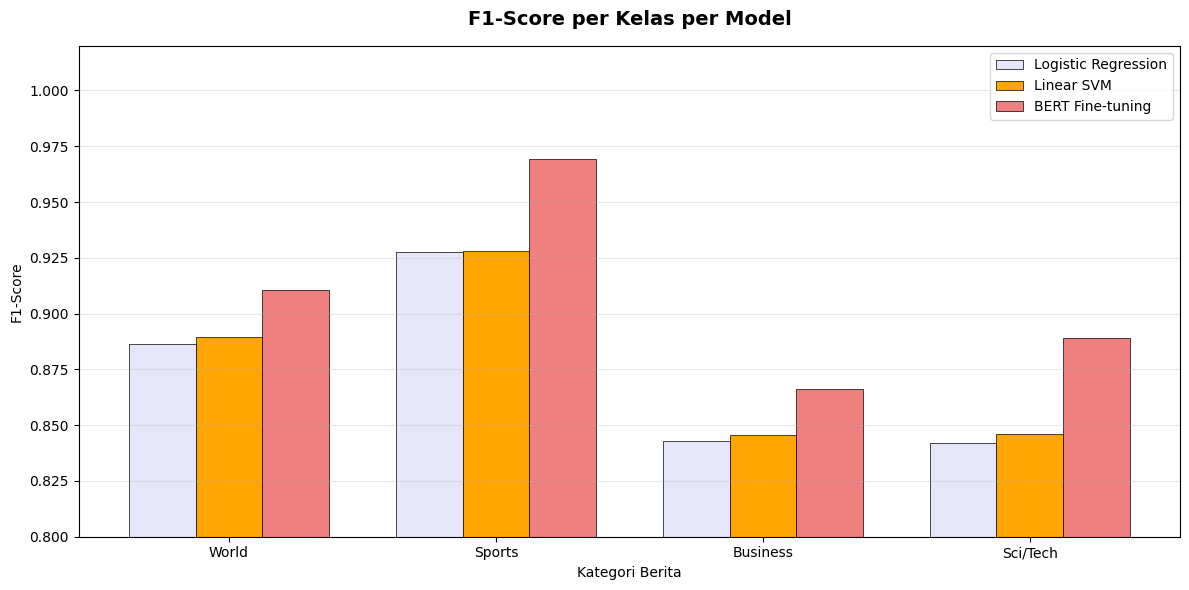

In [35]:
# Visualisasi F1-Score per Kelas per Model

def get_per_class_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    return [report[cls]['f1-score'] for cls in class_names]

f1_lr   = get_per_class_f1(y_test, y_test_pred_lr)
f1_svm  = get_per_class_f1(y_test, y_test_pred_svm)
f1_bert = get_per_class_f1(y_test_true_bert, y_test_pred_bert)

x     = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, f1_lr,   width, label='Logistic Regression', color='lavender', edgecolor='black', linewidth=0.5)
ax.bar(x,         f1_svm,  width, label='Linear SVM',          color='orange', edgecolor='black', linewidth=0.5)
ax.bar(x + width, f1_bert, width, label='BERT Fine-tuning',    color='lightcoral', edgecolor='black', linewidth=0.5)

ax.set_title('F1-Score per Kelas per Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kategori Berita')
ax.set_ylabel('F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0.80, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('f1_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

In [36]:
# Error Analysis BERT (Model Utama)
# Membuat dataframe khusus untuk test set
test_df = df.loc[X_test_bert.index].copy().reset_index(drop=True)
test_df['true_label']  = y_test_true_bert
test_df['pred_bert']   = y_test_pred_bert
test_df['pred_lr']     = list(y_test_pred_lr)
test_df['pred_svm']    = list(y_test_pred_svm)
test_df['true_cat']    = test_df['true_label'].apply(lambda x: class_names[x])
test_df['pred_cat']    = test_df['pred_bert'].apply(lambda x: class_names[x])
test_df['is_wrong_bert'] = test_df['true_label'] != test_df['pred_bert']

wrong_df = test_df[test_df['is_wrong_bert']]
print(f'Total prediksi salah BERT: {len(wrong_df)} dari {len(test_df)} data test')
print(f'Error rate: {len(wrong_df)/len(test_df)*100:.2f}%')
print()
print('Distribusi kesalahan:')
print(wrong_df.groupby(['true_cat', 'pred_cat']).size().sort_values(ascending=False).head(10))

Total prediksi salah BERT: 69 dari 760 data test
Error rate: 9.08%

Distribusi kesalahan:
true_cat  pred_cat
Business  Sci/Tech    16
Sci/Tech  Business    13
Business  World        9
World     Business     8
Sci/Tech  World        7
World     Sports       5
          Sci/Tech     4
Business  Sports       3
Sci/Tech  Sports       2
Sports    Business     1
dtype: int64


In [37]:
# Contoh Berita yang Salah Diklasifikasi BERT
print('Contoh Berita yang Salah Diklasifikasikan oleh Metode BERT')
print('='*65)

# Menampilkan 2 contoh per pasangan kelas yang paling sering salah
error_pairs = wrong_df.groupby(['true_cat', 'pred_cat']).size().sort_values(ascending=False).head(3)

for (true_cat, pred_cat), count in error_pairs.items():
    print(f'\n[True: {true_cat} → Predicted: {pred_cat}] ({count} kasus)')
    sample = wrong_df[(wrong_df['true_cat'] == true_cat) & (wrong_df['pred_cat'] == pred_cat)].head(2)
    for _, row in sample.iterrows():
        print(f'  Title: {row["title"]}')
        print(f'  Desc : {row["description"][:100]}...')
        print()

Contoh Berita yang Salah Diklasifikasikan oleh Metode BERT

[True: Business → Predicted: Sci/Tech] (16 kasus)
  Title: Cisco Systems 1st-Quarter Earnings Rise (Reuters)
  Desc : Reuters - Cisco Systems Inc., the biggest maker\of equipment that directs data over the Internet, on...

  Title: Dell, AOL team up in schools initiative
  Desc : ROUND ROCK, Texas -- Dell Inc. and America Online Inc. announced a partnership Monday to provide 5,0...


[True: Sci/Tech → Predicted: Business] (13 kasus)
  Title: Inside Apple #39;s new Regent Street store
  Desc : With 48 hours left before its official opening, Apple gave us a sneak peek at the new Regent Street ...

  Title: Chicago to Hold EBay Auction to Raise Money for Cultural Programs
  Desc : City officials hope there are people willing to pay plenty of money to own a vintage Playboy Bunny c...


[True: Business → Predicted: World] (9 kasus)
  Title: Megawati kicks off 36th ASEAN economic meeting
  Desc : JAKARTA (Agencies): President Megawa

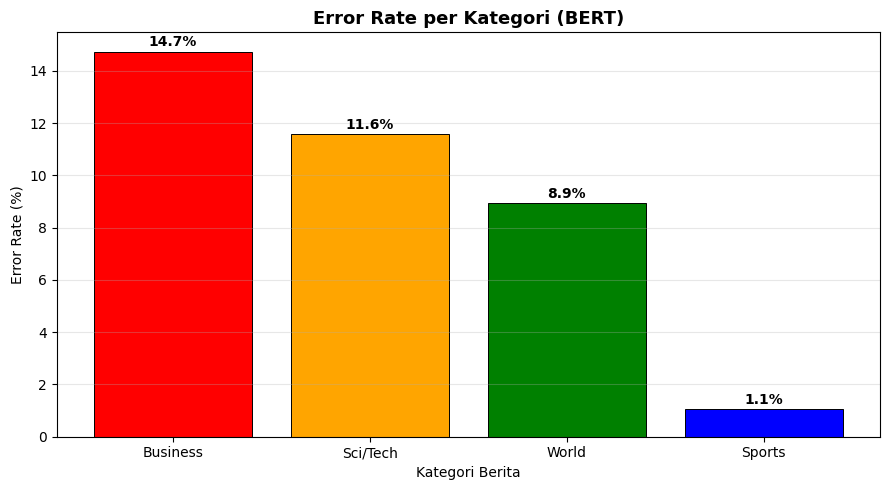

In [38]:
# Visualisasi Error per Kelas
error_per_class = wrong_df['true_cat'].value_counts()
total_per_class = test_df['true_cat'].value_counts()
error_rate_cls  = (error_per_class / total_per_class * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(error_rate_cls.index, error_rate_cls.values,
              color=['red', 'orange', 'green', 'blue'],
              edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, error_rate_cls.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('Error Rate per Kategori (BERT)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Berita')
ax.set_ylabel('Error Rate (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('error_rate_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

# Prediksi untuk Teks Baru

In [40]:
# Mencoba prediksi teks baru dengan model BERT
def predict_text(text, model, tokenizer, device, max_len=128):
    model.eval()

    clean = preprocess_bert(text)
    encoding = tokenizer(
        clean,
        add_special_tokens    = True,
        max_length            = max_len,
        padding               = 'max_length',
        truncation            = True,
        return_attention_mask = True,
        return_tensors        = 'pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).squeeze()

    pred_idx  = torch.argmax(probs).item()
    pred_cat  = class_names[pred_idx]

    return pred_cat, probs.cpu().numpy()


# Teks uji coba
sample_texts = [
    # Business
    "Wall Street stocks fell sharply on Friday as investors reacted to weaker than expected jobs data. The Dow Jones dropped 400 points while the S&P 500 declined 1.2 percent amid growing recession fears.",

    # Sci/Tech
    "NASA successfully launched its new Mars rover mission today. Scientists expect the spacecraft to reach Mars orbit within seven months and begin surface exploration.",

    # Sports
    "The Los Angeles Lakers defeated the Boston Celtics 112-98 in Game 7 of the NBA Finals last night. LeBron James scored 38 points and grabbed 12 rebounds.",

    # World
    "The United Nations Security Council held an emergency session on the escalating conflict in the Middle East, calling for an immediate ceasefire from all parties involved.",

    # Teks ambigu (Business + Tech)
    "Microsoft announced a major investment in artificial intelligence infrastructure, planning to spend $50 billion on data centers and AI chips over the next two years."
]

# Hasil
print('Prediksi Teks Baru dengan BERT-Fine Tuning')
print('-'*65)

for i, text in enumerate(sample_texts):
    pred_cat, probs = predict_text(text, bert_model, tokenizer, device)

    print(f'\n[Teks {i+1}]')
    print(f'Input   : {text[:90]}...' if len(text) > 90 else f'Input   : {text}')
    print(f'Prediksi: {pred_cat} ✅')
    print('Probabilitas per kelas:')
    for cls, prob in zip(class_names, probs):
        bar = '█' * int(prob * 30)
        print(f'  {cls:<12} {bar:<30} {prob*100:.1f}%')

Prediksi Teks Baru dengan BERT-Fine Tuning
-----------------------------------------------------------------

[Teks 1]
Input   : Wall Street stocks fell sharply on Friday as investors reacted to weaker than expected job...
Prediksi: Business ✅
Probabilitas per kelas:
  World                                       0.9%
  Sports                                      0.2%
  Business     █████████████████████████████  98.5%
  Sci/Tech                                    0.4%

[Teks 2]
Input   : NASA successfully launched its new Mars rover mission today. Scientists expect the spacecr...
Prediksi: Sci/Tech ✅
Probabilitas per kelas:
  World                                       1.0%
  Sports                                      0.4%
  Business                                    1.2%
  Sci/Tech     █████████████████████████████  97.4%

[Teks 3]
Input   : The Los Angeles Lakers defeated the Boston Celtics 112-98 in Game 7 of the NBA Finals last...
Prediksi: Sports ✅
Probabilitas per kelas:
  Worl